# Análisis Exploratorio de Datos — ENDIREH 2021

**Curso de Almacenes y Minería de Datos — Práctica 3**

Este notebook presenta y explica los resultados del análisis. El cálculo vive
en los scripts de `src/`, que son el código productivo del proyecto:

| Script | Responsabilidad |
|---|---|
| `src/cleaning/limpieza.py` | Preprocesamiento: duplicados, tipos, códigos de no respuesta, imputación |
| `src/visualization/eda.py` | Medidas de localización y variabilidad |
| `src/visualization/graficas.py` | Construcción de las figuras |

El notebook importa de esos módulos en lugar de repetir sus cálculos, de modo
que cada número tenga un solo origen y el notebook y el reporte no puedan
contradecirse.

> **Antes de ejecutar:** corre `python src/cleaning/limpieza.py` desde la raíz
> del proyecto para generar `data/data-processed/endireh_limpio.parquet`.

## 1. Configuración y carga

Se carga el dataset **ya preprocesado**. El archivo crudo nunca se toca desde
aquí: esa es responsabilidad exclusiva de `limpieza.py`.

In [1]:
# Importa polars como pl
import polars as pl
# Importa numpy como np
import numpy as np
# Importamos modulos de Python para manipular rutas de archivos
import sys
from pathlib import Path

# Agrega la raíz del proyecto al path para poder importar config/ y src/.
# Se resuelve de forma absoluta en vez de usar ".." porque ".." solo funciona
# si Jupyter se abrió desde la carpeta notebooks/; así funciona desde donde sea.
RAIZ = Path.cwd()
if not (RAIZ / "config").exists():
    RAIZ = RAIZ.parent
sys.path.append(str(RAIZ))

# Importa la ruta hacia data/data-processed/ definida en config/rutas.py
from config.rutas import RUTA_DATA_PROCESSED

# Cargar dataset parquet procesado con Polars
df = pl.read_parquet(RUTA_DATA_PROCESSED / "endireh_limpio.parquet")

# Imprime filas y columnas para verificar que se importó correctamente
print("Dimensiones del dataset:", df.shape)
# Suma de factores de expansión: debe rondar los 50 millones de mujeres de 15+
print(f"Población representada: {df['factor_expansion'].sum():,.0f} mujeres de 15 años y más")

# Crea una tabla con las primeras filas para verificar el formato esperado
df.head(3)

Dimensiones del dataset: (105752, 25)
Población representada: 49,144,897 mujeres de 15 años y más


cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta,ingreso_pareja_imputado
i8,cat,i16,cat,f64,f64,cat,i8,cat,i8,i8,cat,f64,i8,cat,i8,cat,i8,cat,i8,cat,i8,f64,i16,bool
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113.0,2021,false
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113.0,2021,false
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13.0,3.0,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227.0,2021,false


## 2. Estado de los datos tras el preprocesamiento

`limpieza.py` ejecuta, en este orden: carga en UTF-8 → validación de columnas →
reparación de encoding → códigos de no respuesta a nulo → conversión de tipos →
eliminación de duplicados → imputación.

Lo que la ejecución reporta sobre el archivo crudo:

| Paso | Resultado |
|---|---|
| Filas crudas | 110,127 |
| Encoding | 409 valores distintos reparados en 9 columnas |
| Códigos de no respuesta | 883 en `edad_primer_union` (98, 99) y 4,058 en `ingreso_pareja` (999997/98/99) |
| Duplicados eliminados | 4,375 filas idénticas |
| Imputación | 4,028 valores de `ingreso_pareja` con la mediana por estrato |
| Filas finales | 105,752 |

El orden de los pasos condiciona el resultado. Los duplicados se eliminan una
vez que las columnas ya tienen su forma definitiva: dos filas del archivo
crudo pueden diferir solo en el código de no respuesta empleado, y solo
resultan idénticas después de convertir esos códigos a nulo.

### Tres tipos de nulo, tres tratamientos

Los nulos del dataset no significan lo mismo, y aplicarles el mismo criterio
introduciría información falsa:

1. **Estructural (no aplica).** `ingreso_pareja` es nulo si y solo si
   `pareja_trabaja = No`. Son 56,894 casos y no se imputan: un ingreso
   inventado para una pareja que no trabaja agrega información que la encuesta
   nunca levantó.
2. **No respuesta.** La pregunta aplicaba pero no se contestó; el valor venía
   con un código centinela. Son 4,028 y sí se imputan, con la mediana por
   `estrato_socioeconomico`. Mediana y no media porque la distribución del
   ingreso está muy sesgada; por estrato y no global porque el ingreso varía
   con el nivel socioeconómico del hogar.
3. **Por diseño del consolidado.** `edad_primer_union` solo tiene valor en las
   mujeres cuya unión terminó. Se conserva como nulo.

In [2]:
# Revisamos el estado de los nulos en el dataset ya limpio: cuantos quedan por
# columna y que proporcion representan del total de filas.
nulos = (
    df.null_count()  # una fila con el conteo de nulos de cada columna
    # transpose la voltea para tener una fila por variable en vez de una columna
    .transpose(include_header=True, header_name="variable", column_names=["nulos"])
    .with_columns((100 * pl.col("nulos") / df.height).round(1).alias("pct"))
    .filter(pl.col("nulos") > 0)  # las columnas completas no aportan a la tabla
    .sort("nulos", descending=True)
)
print("Columnas con valores nulos tras el preprocesamiento:")
print(nulos)

# Comprobaciones de que el preprocesamiento hizo su trabajo.
print(f"\nFilas duplicadas restantes: {df.height - df.unique().height}")
print(f"Entidades de ejemplo: {sorted(df['nom_entidad'].unique().to_list())[6:9]}")

Columnas con valores nulos tras el preprocesamiento:
shape: (3, 3)
┌───────────────────┬───────┬──────┐
│ variable          ┆ nulos ┆ pct  │
│ ---               ┆ ---   ┆ ---  │
│ str               ┆ u32   ┆ f64  │
╞═══════════════════╪═══════╪══════╡
│ edad_primer_union ┆ 82090 ┆ 77.6 │
│ ingreso_pareja    ┆ 56894 ┆ 53.8 │
│ num_hijos         ┆ 19231 ┆ 18.2 │
└───────────────────┴───────┴──────┘

Filas duplicadas restantes: 0
Entidades de ejemplo: ['CIUDAD DE MÉXICO', 'COAHUILA DE ZARAGOZA', 'COLIMA']


## 3. Clasificación de variables (Paso 5)

La tabla distingue **subtipo**, no solo si la variable es cualitativa o
cuantitativa: nominal contra ordinal, discreta contra continua.

Tres variables merecen una advertencia. Sus nombres afirman cosas que los datos
no respaldan, y lo documentamos en vez de asumirlo:

- **`edad_primer_union`**: el 60.2% de sus valores es menor a 10 y solo la tienen
  las mujeres cuya unión terminó (98% de las viudas, 3% de las casadas). No puede
  ser una edad. Su forma sugiere *años transcurridos desde que terminó la unión*.
- **`num_hijos`**: toma únicamente los valores 1, 2, 3 y 4, y el 2 aparece 2,115
  veces contra 36,019 del 3. No es un conteo de hijos, es un código.
- **`nivel_escolaridad`**: sus categorías son `A1, A2, B1, B2, C1, C2`, que no
  corresponden a ningún nivel educativo del catálogo del INEGI.

Se solicitó a la ayudantía el mapeo de columnas del archivo consolidado; hasta
no tenerlo, estas variables se describen por su comportamiento observado.

In [3]:
# Tabla de clasificación del Paso 5: cada diccionario es una fila.
# "Tipo de Dato" lleva el subtipo (nominal/ordinal, discreta/continua), que es
# la distinción que pide la práctica. La marca "(revisar)" señala las variables
# cuyo comportamiento no coincide con lo que su nombre afirma.
clasificacion = [
    # --- Cuantitativas ---
    {"Variable": "ingreso_pareja", "Tipo de Dato": "Cuantitativa continua",
     "Justificación": "Ingreso mensual en pesos; admite cualquier valor real en su rango."},
    {"Variable": "factor_expansion", "Tipo de Dato": "Cuantitativa continua",
     "Justificación": "Ponderador muestral: mujeres de la población que representa cada observación."},
    {"Variable": "edad_primer_union", "Tipo de Dato": "Cuantitativa discreta (revisar)",
     "Justificación": "Declarada en años enteros, pero el 60.2% es menor a 10 y solo la tienen las uniones terminadas: no es una edad."},
    {"Variable": "num_hijos", "Tipo de Dato": "Cualitativa ordinal (revisar)",
     "Justificación": "Solo toma valores 1-4 con distribución no monótona; se comporta como código, no como conteo."},

    # --- Cualitativas ordinales ---
    {"Variable": "estrato_socioeconomico", "Tipo de Dato": "Cualitativa ordinal",
     "Justificación": "Cuatro niveles con jerarquía (1 a 4); admite moda y mediana, no media."},
    {"Variable": "nivel_escolaridad", "Tipo de Dato": "Cualitativa ordinal (revisar)",
     "Justificación": "Categorías A1-C2 aparentemente jerárquicas, pero no corresponden al catálogo educativo del INEGI."},

    # --- Cualitativas nominales ---
    {"Variable": "nom_entidad", "Tipo de Dato": "Cualitativa nominal",
     "Justificación": "Las 32 entidades federativas; sin orden intrínseco."},
    {"Variable": "nom_municipio", "Tipo de Dato": "Cualitativa nominal",
     "Justificación": "1,206 municipios; sin orden intrínseco."},
    {"Variable": "estado_civil_desc", "Tipo de Dato": "Cualitativa nominal",
     "Justificación": "Estado conyugal: casada, soltera, divorciada, etc. Sin jerarquía."},

    # --- Cualitativas dicotómicas (nominales de dos categorías) ---
    {"Variable": "sufrio_violencia_pareja", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Indicador binario: 1 = reportó violencia, 0 = no la reportó."},
    {"Variable": "pareja_trabaja_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Determina si ingreso_pareja aplica."},
    {"Variable": "dinero_propio_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Parte del bloque de autonomía económica."},
    {"Variable": "tiene_ahorros_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Parte del bloque de autonomía económica."},
    {"Variable": "propietaria_vivienda_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Parte del bloque de autonomía económica."},
    {"Variable": "apoyo_gobierno_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Recepción de programas sociales."},
]

# Convierte la lista de diccionarios en DataFrame de Polars
df_clasificacion = pl.DataFrame(clasificacion)

# Configura polars para que no trunque el texto de las justificaciones
with pl.Config(fmt_str_lengths=110, tbl_rows=20, tbl_width_chars=190):
    print(df_clasificacion)

shape: (15, 3)
┌───────────────────────────┬─────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Variable                  ┆ Tipo de Dato                    ┆ Justificación                                                                                                   │
│ ---                       ┆ ---                             ┆ ---                                                                                                             │
│ str                       ┆ str                             ┆ str                                                                                                             │
╞═══════════════════════════╪═════════════════════════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ ingreso_pareja            ┆ Cuantitativa continua           ┆ Ingreso mensual en pesos; admit

## 4. Medidas de localización (Paso 6)

Las funciones provienen de `src/visualization/eda.py`. Para cada variable
cuantitativa se calculan media, mediana, moda, cuartiles y percentiles 10 y 90,
cada uno en versión simple y ponderada por el factor de expansión.

### Dos criterios de cálculo

**Cada variable se filtra por separado.** Al describir `edad_primer_union` se
descartan únicamente las filas con esa columna nula. Que una mujer entre o no
en la muestra de una medida no puede depender de que otra columna tenga valor,
porque eso sesga la muestra sin que se note en el resultado.

**No se recorta el rango de los valores.** Cuando una variable contiene valores
incompatibles con lo que su nombre afirma, el script los cuenta y lo advierte
junto a la medida. Acotar el rango hasta que la cifra parezca razonable produce
un número que describe al filtro y no a la población: en `edad_primer_union`,
exigir un mínimo de 10 años deja fuera 14,239 de los 23,662 casos válidos.

La ponderación se aplica también a la mediana y a los cuantiles, no solo a la
media. Ponderar una medida de tendencia central y dejar las demás sin ponderar
haría que las dos columnas de la tabla no fueran comparables entre sí. Como ni
polars ni numpy ofrecen cuantiles con pesos, `eda.py` implementa la función.

In [4]:
# Importamos las funciones de cálculo desde el script de EDA. El notebook
# muestra los resultados; el cálculo ocurre en src/visualization/eda.py.
from src.visualization.eda import seccion_localizacion

# Imprime media, mediana, moda, Q1, Q3, P10 y P90, simples y ponderadas, para
# cada variable cuantitativa, junto con el aviso de coherencia cuando aplica.
seccion_localizacion(df)


 PASO 6: MEDIDAS DE LOCALIZACION

La media ponderada usa factor_expansion. La mediana, los cuartiles y
los percentiles ponderados se calculan con una funcion propia, porque
ni polars ni numpy ofrecen cuantiles con pesos.

--- edad_primer_union
    n = 23,662 observaciones | poblacion estimada = 11,084,038 mujeres
    [!] AVISO: 14,239 valores (60.2%) son menores a 10. Una edad a la primera union no puede serlo.

    Medida         Sin ponderar      Ponderada
    ------------------------------------------
    Media                 10.03           9.70
    Mediana (Q2)           6.00           6.00
    Moda                   0.00           0.00
    Q1                     2.00           2.00
    Q3                    15.00          15.00
    P10                    0.00           0.00
    P90                   25.00          25.00

    Diferencia media ponderada - media simple: -0.33

--- num_hijos
    n = 86,521 observaciones | poblacion estimada = 36,688,742 mujeres
    [!] AVISO: solo 

## 5. Medidas de variabilidad (Paso 7)

Rango, varianza, desviación estándar, coeficiente de variación e IQR,
comparando el grupo que reportó violencia de pareja contra el que no.

El CV es la medida central de esta sección porque expresa la dispersión como
porcentaje de la media, lo que permite comparar grupos cuyas medias difieren.
La desviación estándar por sí sola no lo permite.

**Limitación.** Estas medidas van sin ponderar: describen la dispersión dentro
de cada grupo de la muestra, no estiman un parámetro poblacional. Ponderarlas
exigiría una varianza con corrección por diseño muestral complejo, fuera del
alcance de esta práctica.

In [5]:
from src.visualization.eda import seccion_variabilidad

# Compara rango, varianza, desviación, CV e IQR entre el total, el grupo que
# reportó violencia y el que no, para cada variable cuantitativa.
seccion_variabilidad(df)


 PASO 7: MEDIDAS DE VARIABILIDAD

Comparacion entre el grupo que reporto violencia de pareja y el que no.
Las medidas van sin ponderar: el CV compara dispersion relativa dentro
de cada grupo, no estima un total poblacional. Es una limitacion a
declarar en el reporte.

--- edad_primer_union
    Medida                   Total   Con violencia   Sin violencia
    ------------------------------------------------------------
    n                       23,662           8,467          15,195
    Media                    10.03           10.03           10.03
    Rango                    76.00           72.00           76.00
    Varianza                114.90          110.52          117.35
    Desv. estandar           10.72           10.51           10.83
    CV (%)                  106.86          104.86          107.96
    IQR                      13.00           13.00           13.00

    Razon de CV (con/sin): 0.97

--- num_hijos
    Medida                   Total   Con violencia   Sin vi


--- ingreso_pareja
    Medida                   Total   Con violencia   Sin violencia
    ------------------------------------------------------------
    n                       48,858          10,072          38,786
    Media                 3,731.39        3,212.59        3,866.12
    Rango               800,000.00       80,000.00      800,000.00
    Varianza         50,039,813.41   22,927,409.72   56,993,123.76
    Desv. estandar        7,073.88        4,788.26        7,549.38
    CV (%)                  189.58          149.05          195.27
    IQR                   3,500.00        2,600.00        3,900.00

    Razon de CV (con/sin): 0.76


## 6. Visualizaciones

Las figuras se construyen en `src/visualization/graficas.py` y se guardan en
`reports/figuras/`. Aquí se generan y se muestran para explicarlas.

Criterios de diseño aplicados:

- **Un solo color en las gráficas de una serie.** Colorear las barras según su
  posición en el ranking sugiere categorías que no existen; el orden ya lo
  comunica la posición.
- **El par azul/naranja está verificado para daltonismo**, no elegido a ojo:
  ΔE de 24.7 en protanopia, contra un mínimo recomendado de 8.
- **Toda prevalencia está ponderada** por el factor de expansión, y el pie de
  cada figura lo declara junto con el tamaño de muestra.

In [6]:
# generar_graficas construye las cuatro figuras; RUTA_FIGURAS es la carpeta
# donde las deja, definida a partir de config/rutas.py.
from src.visualization.graficas import generar_graficas, RUTA_FIGURAS
from IPython.display import Image, display

# Escribe los PNG en reports/figuras/, creando la carpeta si no existe.
generar_graficas()

[graficas] Dataset: 105,752 filas. Guardando en /home/claude/repo/reports/figuras


[graficas] reports/figuras/01_distribucion_edad_primer_union.png
[graficas] reports/figuras/02_ingreso_por_violencia.png


[graficas] reports/figuras/03_prevalencia_por_entidad.png
[graficas] reports/figuras/04_prevalencia_por_estado_civil.png
[graficas] Listo: 4 figuras generadas.


### 6.1 La variable `edad_primer_union` no se comporta como una edad

El histograma muestra picos en 10, 15, 20, 25 y 30, el patrón que deja el
redondeo cuando alguien declara una cantidad de años que no recuerda con
precisión. La franja sombreada cubre el 60.2% de los valores, todos por debajo
de 10 y por tanto imposibles como edad a la primera unión.

Ese patrón, junto con la distribución de los nulos —la variable tiene valor en
el 98% de las viudas y en el 3% de las casadas—, apunta a que mide el tiempo
transcurrido desde que la unión terminó.

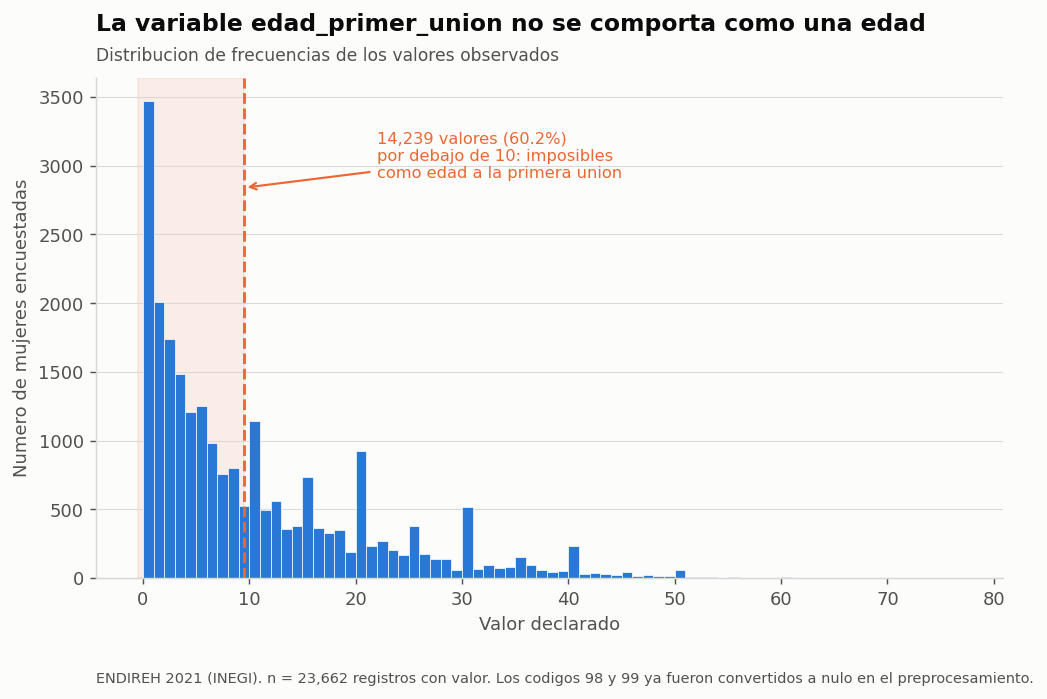

In [7]:
# Mostramos la figura 1 ya generada, leyéndola desde reports/figuras/.
display(Image(filename=str(RUTA_FIGURAS / "01_distribucion_edad_primer_union.png")))

### 6.2 Dónde se separan los ingresos

Esta comparación es la que sostiene las respuestas a las preguntas 3 y 5 del
cuestionario.

Las dos distribuciones son **casi idénticas en la mitad baja** (P10 de \$500 en
ambos grupos, mediana de \$1,500 contra \$1,600) y **se separan en la mitad
alta** (Q3 de \$3,500 contra \$5,000; P90 de \$8,000 contra \$10,000). Ahí está
el origen del CV de 149% contra 195% de la sección anterior: la diferencia de
dispersión proviene de la cola superior, no del centro.

Por eso la lectura precisa no es que las parejas violentas ganen menos, sino
que entre las mujeres que reportaron violencia casi no hay parejas de ingresos
altos.

> **Lectura ética.** La asociación no permite concluir que el bajo ingreso cause
> violencia. Una explicación igual de compatible con el dato es que las mujeres
> con parejas de ingresos altos **reporten** menos, no que sufran menos. El
> diseño transversal de la encuesta no distingue entre ambas.

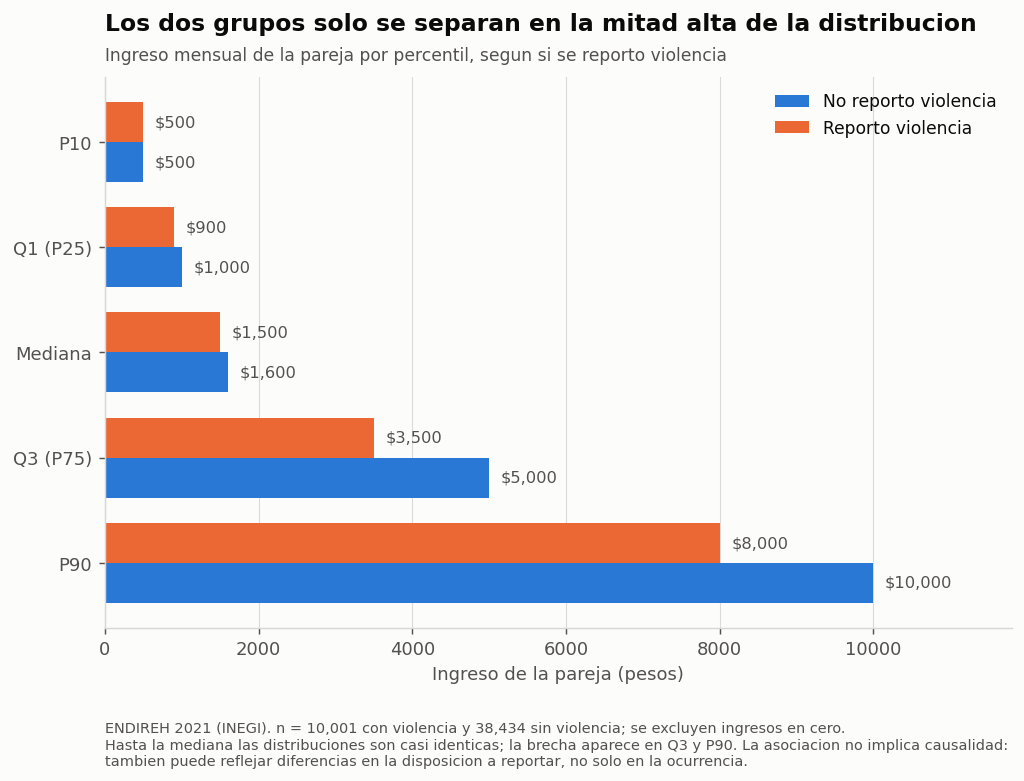

In [8]:
# Mostramos la figura 2 ya generada, leyéndola desde reports/figuras/.
display(Image(filename=str(RUTA_FIGURAS / "02_ingreso_por_violencia.png")))

### 6.3 y 6.4 Prevalencia por entidad y por estado conyugal

La prevalencia nacional ponderada es de **17.8%**. Por entidad el rango va de
11.2% a 23.0%, una variación moderada.

Por estado conyugal el contraste es mucho mayor: las mujeres separadas (45.7%) y
divorciadas (44.4%) reportan cerca del triple que las casadas (14.1%).

> **Lectura ética.** Este resultado es el más fácil de malinterpretar de todo el
> análisis. No dice que separarse provoque violencia; lo más razonable es lo
> contrario, que la violencia haya sido motivo de la separación. La encuesta es
> transversal y no permite establecer la dirección causal.
>
> Del mismo modo, una entidad con prevalencia alta no es "más violenta": puede
> tener mejores condiciones para que las mujeres reporten. Todas estas cifras
> miden **lo reportado en la encuesta**, no la ocurrencia real del fenómeno.

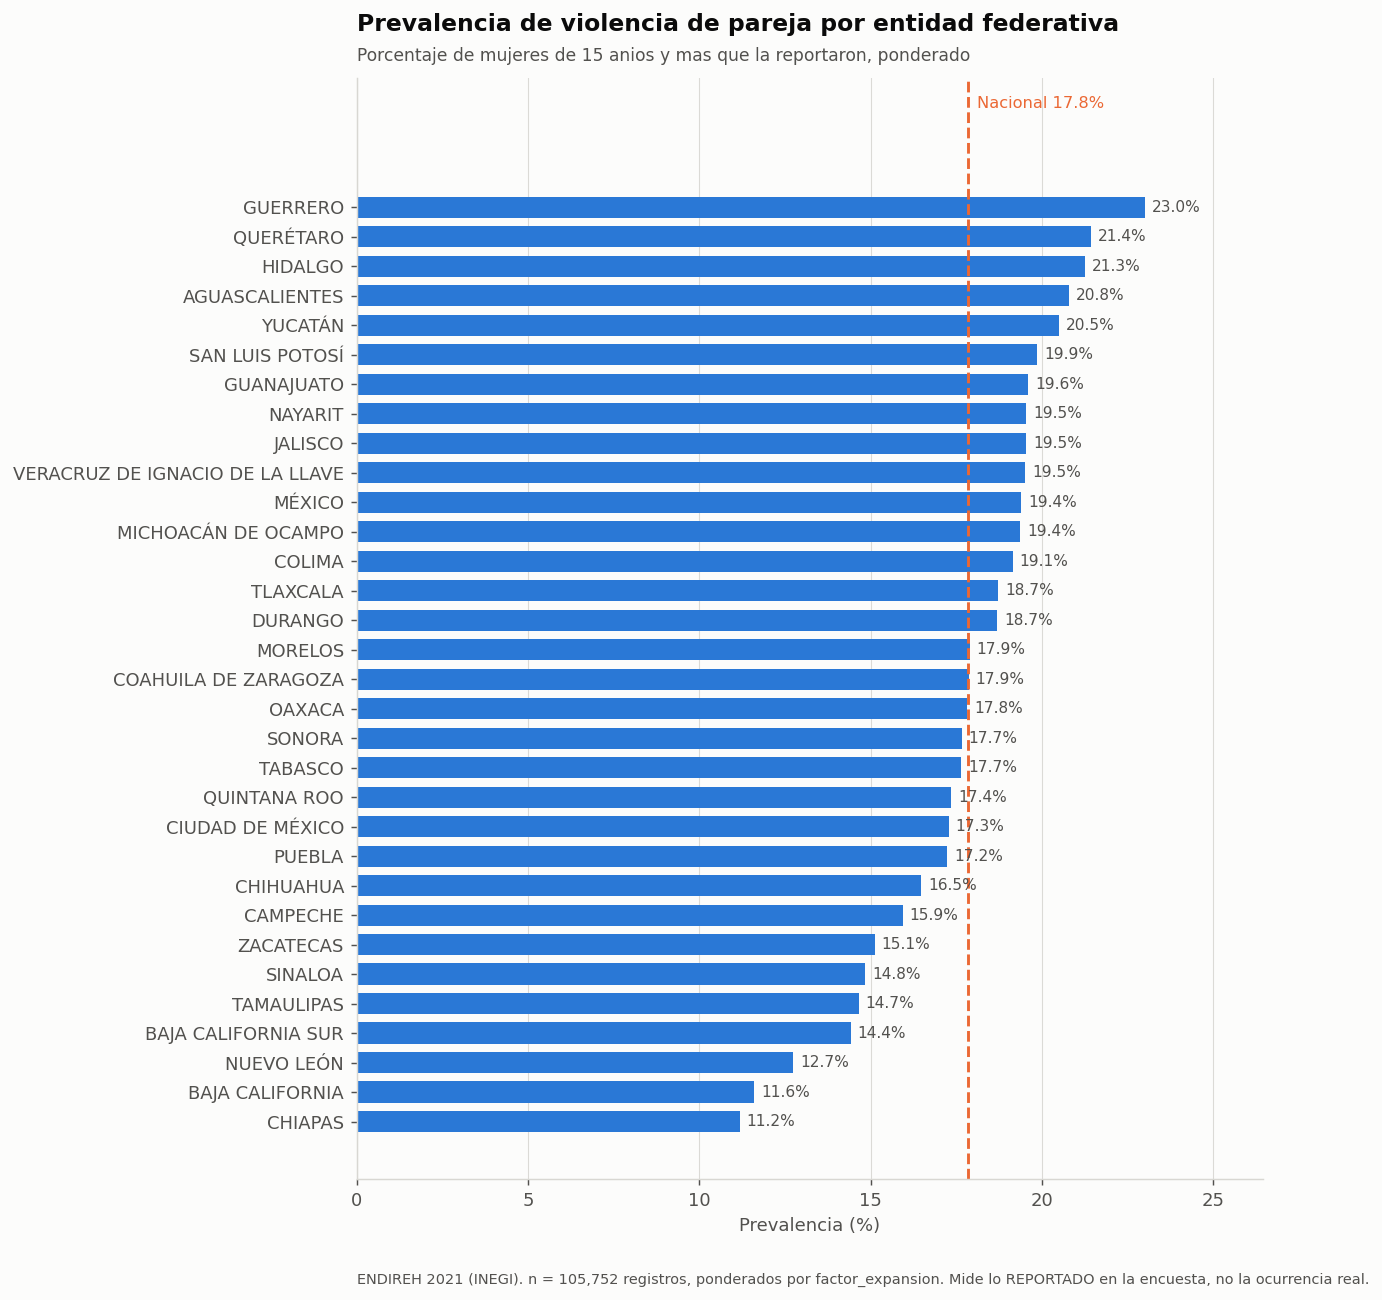

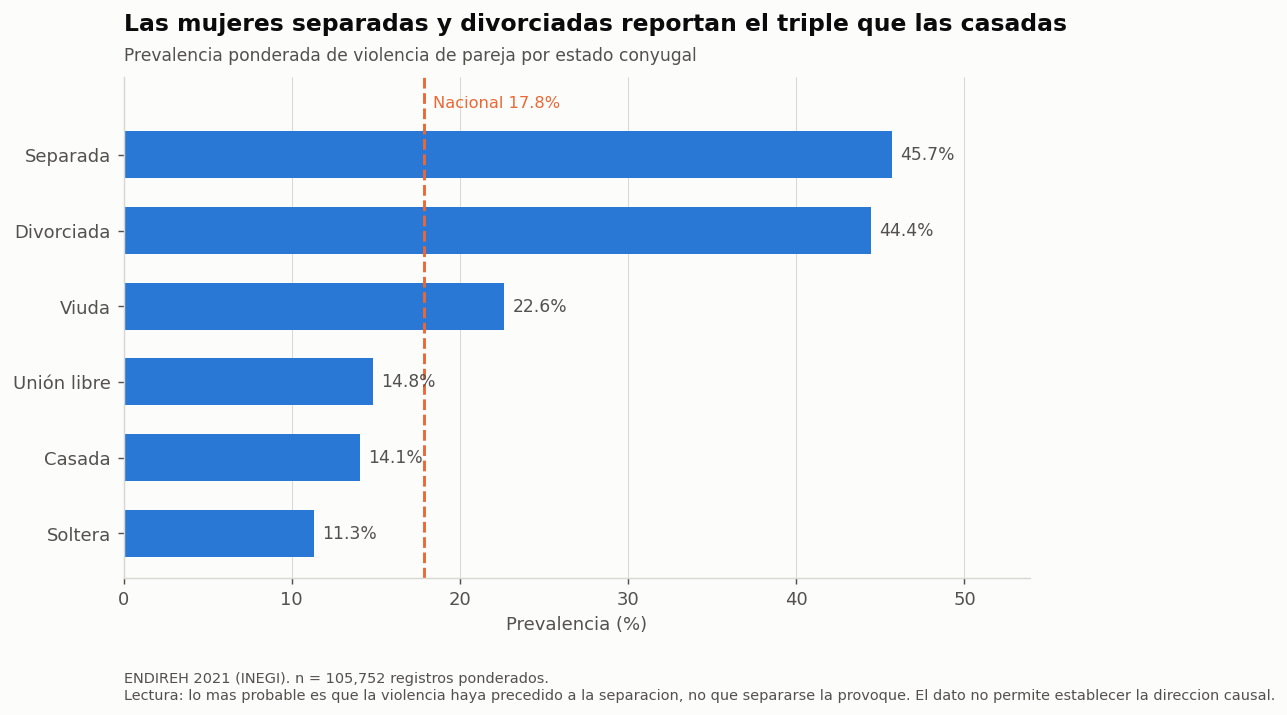

In [9]:
# Mostramos las figuras 3 y 4 ya generadas.
display(Image(filename=str(RUTA_FIGURAS / "03_prevalencia_por_entidad.png")))
display(Image(filename=str(RUTA_FIGURAS / "04_prevalencia_por_estado_civil.png")))

## 7. Hallazgos y limitaciones

### Hallazgos

1. **El archivo consolidado contenía 4,375 filas idénticas** (4.0% del total) y
   el encoding dañado desde el origen en 409 valores distintos.
2. **Los nulos son de tres naturalezas distintas** y reciben tratamientos
   distintos. El 53.8% de nulos de `ingreso_pareja` es estructural y no admite
   imputación.
3. **La diferencia de ingreso entre grupos está en la cola superior**, no en el
   centro de la distribución.
4. **El estado conyugal discrimina mucho más que la geografía**: el rango entre
   estados conyugales (11.3% a 45.7%) triplica al rango entre entidades
   (11.2% a 23.0%).

### Limitaciones

1. **Tres variables tienen significado no confirmado**: `edad_primer_union`,
   `num_hijos` y `nivel_escolaridad`. Sus medidas se calculan y se reportan,
   pero su interpretación depende del mapeo de columnas del archivo
   consolidado, que se solicitó a la ayudantía.
2. **Las medidas de variabilidad no están ponderadas**, por lo indicado en la
   sección 5.
3. **La deduplicación reduce la población representada en 1,378,572 mujeres**,
   el 2.73%: la suma de factores pasa de 50,523,469 a 49,144,897, y se aleja
   del total oficial de mujeres de 15 años y más. Las filas repetidas se
   concentran donde falta información: el 96.2% de ellas tiene nulas tanto
   `edad_primer_union` como `ingreso_pareja`, frente al 44.2% del conjunto. En
   las filas que sí traen ambas variables hay una sola coincidencia en 12,091
   registros, contra 4,239 en 48,678 sin ninguna de las dos. El patrón indica
   que son mujeres distintas indistinguibles entre sí con las 24 variables
   disponibles, no capturas repetidas. Se eliminan porque la práctica lo pide;
   con un identificador de registro el criterio sería otro.
4. **La media de `edad_primer_union` es 10.03 en los tres grupos** —total, con
   violencia y sin violencia— idéntica hasta el segundo decimal, lo que sugiere
   que la variable no guarda relación con `sufrio_violencia_pareja`.
5. **Todo el análisis describe lo reportado en la ENDIREH**, no la ocurrencia
   real de la violencia. Una prevalencia baja puede reflejar menor ocurrencia o
   mayor silencio, y los datos no distinguen entre ambas.